In [1]:
import gymnasium as gym
import gymnasium_robotics
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import os
import shutil
import base64
from collections import deque
from IPython.display import HTML, display
from gymnasium.wrappers import RecordVideo

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

Using device: cpu


In [2]:
# Environment
OBS_DIM = 10          # observation
GOAL_DIM = 3          # desired_goal / achieved_goal
STATE_DIM = OBS_DIM + 2 * GOAL_DIM   # observation + desired_goal + achieved_goal = 16
ACTION_DIM = 4
MAX_ACTION = 1.0

# SAC hyperparameters
HIDDEN_DIM = 256
ACTOR_LR = 1e-3
CRITIC_LR = 1e-3
ALPHA_LR = 1e-3          # for automatic entropy tuning
GAMMA = 0.99
TAU = 0.01              # soft target update coefficient (increased from 0.005)
BATCH_SIZE = 128        # smaller batch = more frequent updates
BUFFER_SIZE = 1_000_000
START_STEPS = 500       # reduce random exploration
MAX_EPISODES = 2000      # far fewer than REINFORCE because HER makes it sample‑efficient
MAX_STEPS = 50           # default FetchReach episode length
UPDATE_AFTER = 500      # start training after this many env steps (reduced)
UPDATE_EVERY = 1         # update networks every N env steps

# HER
HER_K = 4               # number of HER relabeled goals per transition
GOAL_SELECTION = "future"

# Logging & Video
PRINT_INTERVAL = 100
VIDEO_DIR = "./sac_her_scratch_videos"
os.makedirs(VIDEO_DIR, exist_ok=True)

In [3]:
def flatten_obs(obs_dict):
    """Concatenate observation, desired_goal, achieved_goal."""
    return np.concatenate([
        obs_dict["observation"],
        obs_dict["desired_goal"],
        obs_dict["achieved_goal"]
    ]).astype(np.float32)


def embed_mp4_in_notebook(video_path, width=600):
    with open(video_path, "rb") as f:
        video_data = f.read()
    b64 = base64.b64encode(video_data).decode()
    return HTML(f'<video width="{width}" controls><source src="data:video/mp4;base64,{b64}"></video>')


class DenseRewardWrapper(gym.Wrapper):
    """
    Dense reward wrapper based on final distance and end-effector stop condition.

    An episode terminates early only when the end-effector is within threshold
    and its speed is below velocity_threshold. Success bonus scales with remaining time.
    """
    def __init__(self, env, base_scale=3.0, success_bonus=50.0, threshold=0.05, velocity_threshold=1e-3):
        super().__init__(env)
        self.base_scale = base_scale
        self.success_bonus = success_bonus
        self.threshold = threshold
        self.velocity_threshold = velocity_threshold

        spec = getattr(env, "spec", None)
        max_steps_from_spec = getattr(spec, "max_episode_steps", None) if spec is not None else None
        self.max_episode_steps = getattr(env, "_max_episode_steps", max_steps_from_spec)

    def step(self, action):
        obs, _, terminated, truncated, info = self.env.step(action)
        achieved = obs["achieved_goal"]
        desired = obs["desired_goal"]
        distance = np.linalg.norm(achieved - desired)

        # FetchReach observation includes end-effector linear velocity in the last 3 entries.
        ee_velocity = obs["observation"][-3:]
        ee_speed = np.linalg.norm(ee_velocity)

        reward = -distance * self.base_scale

        # Success requires both reaching target and coming to a near stop.
        success_and_stopped = (distance < self.threshold) and (ee_speed <= self.velocity_threshold)
        elapsed_steps = getattr(self.env, "_elapsed_steps", None)

        time_bonus = 0.0
        remaining_ratio = 0.0
        if success_and_stopped:
            if (self.max_episode_steps is not None) and (elapsed_steps is not None):
                remaining_steps = max(self.max_episode_steps - elapsed_steps, 0)
                remaining_ratio = remaining_steps / float(self.max_episode_steps)

            # Bonus is fully time-based: earlier successful stop => larger bonus.
            time_bonus = self.success_bonus * remaining_ratio
            reward += time_bonus
            terminated = True

        info["distance_to_goal"] = float(distance)
        info["ee_speed"] = float(ee_speed)
        info["stopped_at_target"] = bool(success_and_stopped)
        info["remaining_time_ratio"] = float(remaining_ratio)
        info["time_bonus"] = float(time_bonus)
        return obs, reward, terminated, truncated, info

In [4]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=HIDDEN_DIM, max_action=MAX_ACTION):
        super().__init__()
        self.max_action = max_action
        
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)
        
        # Initialize weights
        self.apply(self._init_weights)
        
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
            nn.init.constant_(m.bias, 0.0)
        # Set log_std bias to small negative values for stability
        if isinstance(m, nn.Linear) and m.out_features == ACTION_DIM:
            nn.init.constant_(m.bias, -0.5)
    
    def forward(self, state):
        x = self.net(state)
        mean = self.mean(x)
        log_std = self.log_std(x)
        log_std = torch.clamp(log_std, -20, 2)
        return mean, log_std
    
    def get_action(self, state_np, deterministic=False):
        state = torch.FloatTensor(state_np).unsqueeze(0).to(device)
        mean, log_std = self.forward(state)
        std = log_std.exp()
        
        if deterministic:
            action = torch.tanh(mean) * self.max_action
        else:
            normal = torch.distributions.Normal(mean, std)
            z = normal.rsample()  # reparameterization trick
            action = torch.tanh(z) * self.max_action
        
        return action.cpu().detach().numpy().squeeze(0)
    
    def evaluate(self, state, epsilon=1e-6):
        """Return action, log_prob, and pre‑tanh mean for entropy calculation."""
        mean, log_std = self.forward(state)
        std = log_std.exp()
        normal = torch.distributions.Normal(mean, std)
        z = normal.rsample()
        action = torch.tanh(z)
        
        # Log probability with tanh correction
        log_prob = normal.log_prob(z) - torch.log(1 - action.pow(2) + epsilon)
        log_prob = log_prob.sum(dim=-1, keepdim=True)
        
        # Scale action to environment bounds
        action_scaled = action * self.max_action
        return action_scaled, log_prob, z, mean, log_std

In [5]:
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=HIDDEN_DIM):
        super().__init__()
        # Q1
        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        # Q2
        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
            nn.init.constant_(m.bias, 0.0)
    
    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        q1 = self.q1(x)
        q2 = self.q2(x)
        return q1, q2

In [6]:
class HERReplayBuffer:
    def __init__(self, capacity, state_dim, action_dim, goal_dim, k=HER_K, strategy="future"):
        self.capacity = capacity
        self.k = k
        self.strategy = strategy

        self.base_scale = 3.0
        self.threshold = 0.05

        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, action_dim), dtype=np.float32)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros(capacity, dtype=np.float32)
        self.desired_goals = np.zeros((capacity, goal_dim), dtype=np.float32)
        self.achieved_goals = np.zeros((capacity, goal_dim), dtype=np.float32)
        self.next_achieved_goals = np.zeros((capacity, goal_dim), dtype=np.float32)

        self.ptr = 0
        self.size = 0

    def store_episode(self, episode):
        """
        episode: list of dicts with keys:
            'state', 'action', 'reward', 'next_state', 'done',
            'desired_goal', 'achieved_goal', 'next_achieved_goal'
        """
        T = len(episode)
        for t in range(T):
            self._store_transition(episode[t])

        # HER relabeling: replace the goal with a strictly future achieved_goal.
        for t in range(T):
            transition = episode[t]
            if self.strategy == "future":
                # Standard HER "future" strategy samples from times t' > t.
                candidate_start = t + 1
                if candidate_start >= T:
                    continue
                num_candidates = T - candidate_start
                num_samples = min(self.k, num_candidates)
                future_indices = np.random.choice(
                    range(candidate_start, T),
                    size=num_samples,
                    replace=False
                )
            elif self.strategy == "final":
                future_indices = [T - 1] * self.k
            else:
                raise ValueError(f"Unknown strategy: {self.strategy}")

            for idx in future_indices:
                new_goal = episode[idx]["achieved_goal"].copy()

                # Simple dense reward: distance to the relabeled goal.
                # Done is set when next_achieved_goal reaches the new goal.
                # We cannot check velocity for relabeled transitions (no obs available),
                # so we use pure distance — consistent with HER relabeling design.
                dist = np.linalg.norm(transition["next_achieved_goal"] - new_goal)
                new_reward = -dist * self.base_scale
                relabeled_done = float(dist < self.threshold)

                relabeled_transition = transition.copy()
                relabeled_transition["desired_goal"] = new_goal
                relabeled_transition["reward"] = new_reward
                relabeled_transition["done"] = relabeled_done

                # Rebuild state/next_state with the new goal substituted in.
                relabeled_transition["state"] = np.concatenate([
                    transition["state"][:OBS_DIM],
                    new_goal,
                    transition["achieved_goal"]
                ]).astype(np.float32)
                relabeled_transition["next_state"] = np.concatenate([
                    transition["next_state"][:OBS_DIM],
                    new_goal,
                    transition["next_achieved_goal"]
                ]).astype(np.float32)

                self._store_transition(relabeled_transition)

    def _store_transition(self, trans):
        idx = self.ptr
        self.states[idx] = trans["state"]
        self.actions[idx] = trans["action"]
        self.rewards[idx] = trans["reward"]
        self.next_states[idx] = trans["next_state"]
        self.dones[idx] = trans["done"]
        self.desired_goals[idx] = trans["desired_goal"]
        self.achieved_goals[idx] = trans["achieved_goal"]
        self.next_achieved_goals[idx] = trans["next_achieved_goal"]

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        indices = np.random.randint(0, self.size, size=batch_size)

        states = torch.FloatTensor(self.states[indices]).to(device)
        actions = torch.FloatTensor(self.actions[indices]).to(device)
        rewards = torch.FloatTensor(self.rewards[indices]).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(self.next_states[indices]).to(device)
        dones = torch.FloatTensor(self.dones[indices]).unsqueeze(1).to(device)
        desired_goals = torch.FloatTensor(self.desired_goals[indices]).to(device)

        return states, actions, rewards, next_states, dones, desired_goals

In [7]:
class SACAgent:
    def __init__(self):
        self.actor = Actor(STATE_DIM, ACTION_DIM).to(device)
        self.critic = Critic(STATE_DIM, ACTION_DIM).to(device)
        self.critic_target = Critic(STATE_DIM, ACTION_DIM).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        
        self.actor_optim = optim.Adam(self.actor.parameters(), lr=ACTOR_LR)
        self.critic_optim = optim.Adam(self.critic.parameters(), lr=CRITIC_LR)
        
        # Automatic entropy tuning
        self.target_entropy = -ACTION_DIM
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha = self.log_alpha.exp().item()
        self.alpha_optim = optim.Adam([self.log_alpha], lr=ALPHA_LR)
        
        self.total_steps = 0
    
    def select_action(self, state_np, evaluate=False):
        """Sample action (or deterministic for eval)."""
        if evaluate:
            return self.actor.get_action(state_np, deterministic=True)
        else:
            return self.actor.get_action(state_np, deterministic=False)
    
    def update(self, replay_buffer):
        if replay_buffer.size < BATCH_SIZE:
            return None
        
        states, actions, rewards, next_states, dones, desired_goals = replay_buffer.sample(BATCH_SIZE)
        
        # Concatenate desired goal to state
        states_with_goal = states  # already includes desired_goal and achieved_goal
        next_states_with_goal = next_states
        
        # --- Update Critic ---
        with torch.no_grad():
            next_actions, next_log_probs, _, _, _ = self.actor.evaluate(next_states_with_goal)
            q1_next, q2_next = self.critic_target(next_states_with_goal, next_actions)
            q_next = torch.min(q1_next, q2_next) - self.alpha * next_log_probs
            q_target = rewards + (1 - dones) * GAMMA * q_next
        
        q1, q2 = self.critic(states_with_goal, actions)
        critic_loss = F.mse_loss(q1, q_target) + F.mse_loss(q2, q_target)
        
        self.critic_optim.zero_grad()
        critic_loss.backward()
        self.critic_optim.step()
        
        # --- Update Actor ---
        actions_new, log_probs, _, _, _ = self.actor.evaluate(states_with_goal)
        q1_new, q2_new = self.critic(states_with_goal, actions_new)
        q_new = torch.min(q1_new, q2_new)
        actor_loss = (self.alpha * log_probs - q_new).mean()
        
        self.actor_optim.zero_grad()
        actor_loss.backward()
        self.actor_optim.step()
        
        # --- Update Alpha ---
        alpha_loss = -(self.log_alpha * (log_probs.detach() + self.target_entropy)).mean()
        
        self.alpha_optim.zero_grad()
        alpha_loss.backward()
        self.alpha_optim.step()
        self.alpha = self.log_alpha.exp().item()
        
        # --- Soft target update ---
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)
        
        self.total_steps += 1
        return {
            "critic_loss": critic_loss.item(),
            "actor_loss": actor_loss.item(),
            "alpha_loss": alpha_loss.item(),
            "alpha": self.alpha
        }

In [ ]:
import time

def train_sac_her():
    env = gym.make("FetchReach-v4", render_mode="rgb_array")
    env = DenseRewardWrapper(env, base_scale=3.0, success_bonus=50.0, threshold=0.05)
    agent = SACAgent()
    replay_buffer = HERReplayBuffer(BUFFER_SIZE, STATE_DIM, ACTION_DIM, GOAL_DIM, k=HER_K, strategy=GOAL_SELECTION)

    episode_rewards = []
    success_history = []
    final_distances = []
    episode_times = []  # Track wall-clock time per episode
    loss_history = {"critic": [], "actor": [], "alpha": []}
    best_success = 0.0

    episode = 0
    total_env_steps = 0
    training_start_time = time.time()

    while episode < MAX_EPISODES:
        episode_start_time = time.time()
        obs_dict, _ = env.reset()
        state = flatten_obs(obs_dict)
        episode_transitions = []
        ep_reward = 0.0
        done = False

        for step in range(MAX_STEPS):
            # Select action
            if total_env_steps < START_STEPS:
                action = env.action_space.sample()
            else:
                action = agent.select_action(state)

            next_obs_dict, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = flatten_obs(next_obs_dict)

            # Store transition
            transition = {
                "state": state,
                "action": action,
                "reward": reward,
                "next_state": next_state,
                "done": float(done),
                "desired_goal": obs_dict["desired_goal"],
                "achieved_goal": obs_dict["achieved_goal"],
                "next_achieved_goal": next_obs_dict["achieved_goal"]
            }
            episode_transitions.append(transition)

            state = next_state
            obs_dict = next_obs_dict
            ep_reward += reward
            total_env_steps += 1

            if done:
                break

        episode_elapsed = time.time() - episode_start_time
        episode_times.append(episode_elapsed)

        # Store episode in replay buffer (with HER relabeling)
        replay_buffer.store_episode(episode_transitions)
        episode_rewards.append(ep_reward)

        # Check success (original goal)
        final_dist = np.linalg.norm(obs_dict["achieved_goal"] - obs_dict["desired_goal"])
        final_distances.append(final_dist)
        success = 1 if final_dist < 0.05 else 0
        success_history.append(success)

        # Perform updates
        if total_env_steps >= UPDATE_AFTER:
            for _ in range(min(50, total_env_steps)):  # At least 50 updates per episode after warmup
                loss_info = agent.update(replay_buffer)
                if loss_info:
                    loss_history["critic"].append(loss_info["critic_loss"])
                    loss_history["actor"].append(loss_info["actor_loss"])
                    loss_history["alpha"].append(loss_info["alpha_loss"])

        # Logging
        if (episode + 1) % PRINT_INTERVAL == 0:
            avg_reward = np.mean(episode_rewards[-PRINT_INTERVAL:])
            success_rate = np.mean(success_history[-PRINT_INTERVAL:]) * 100
            avg_dist = np.mean(final_distances[-PRINT_INTERVAL:])
            avg_critic_loss = np.mean(loss_history["critic"][-PRINT_INTERVAL:]) if loss_history["critic"] else 0.0
            avg_actor_loss = np.mean(loss_history["actor"][-PRINT_INTERVAL:]) if loss_history["actor"] else 0.0
            avg_ep_time = np.mean(episode_times[-PRINT_INTERVAL:])
            elapsed_total = time.time() - training_start_time
            print(f"Episode {episode+1:3d} | Avg Reward: {avg_reward:6.2f} | "
                  f"Success: {success_rate:5.1f}% | Avg Final Dist: {avg_dist:.3f} | "
                  f"Critic Loss: {avg_critic_loss:.4f} | Actor Loss: {avg_actor_loss:.4f} | "
                  f"Avg Ep Time: {avg_ep_time:.2f}s | Total Time: {elapsed_total/60:.1f}min")

        # Save best model
        current_success = np.mean(success_history[-10:]) if len(success_history) >= 10 else 0.0
        if current_success > best_success:
            best_success = current_success
            torch.save(agent.actor.state_dict(), "sac_her_actor_best.pt")

        episode += 1

    env.close()
    return agent, episode_rewards, success_history, final_distances, episode_times

# Run training
agent, rewards, successes, distances, episode_times = train_sac_her()

Episode 100 | Avg Reward: -24.00 | Success:   8.0% | Avg Final Dist: 0.230 | Critic Loss: 1.0833 | Actor Loss: 0.6699
Episode 200 | Avg Reward:  11.01 | Success:  59.0% | Avg Final Dist: 0.082 | Critic Loss: 5.1247 | Actor Loss: 0.3325
Episode 300 | Avg Reward:   7.28 | Success:  45.0% | Avg Final Dist: 0.072 | Critic Loss: 4.8386 | Actor Loss: 0.2054
Episode 400 | Avg Reward:   3.74 | Success:  43.0% | Avg Final Dist: 0.092 | Critic Loss: 6.2567 | Actor Loss: 0.2148
Episode 500 | Avg Reward:   2.12 | Success:  38.0% | Avg Final Dist: 0.091 | Critic Loss: 5.5453 | Actor Loss: 0.0932
Episode 600 | Avg Reward:   2.26 | Success:  37.0% | Avg Final Dist: 0.086 | Critic Loss: 6.4425 | Actor Loss: 0.1207
Episode 700 | Avg Reward:   4.05 | Success:  40.0% | Avg Final Dist: 0.083 | Critic Loss: 8.2278 | Actor Loss: 0.1196
Episode 800 | Avg Reward:   4.19 | Success:  41.0% | Avg Final Dist: 0.084 | Critic Loss: 5.2430 | Actor Loss: 0.1209
Episode 900 | Avg Reward:   2.08 | Success:  40.0% | Avg

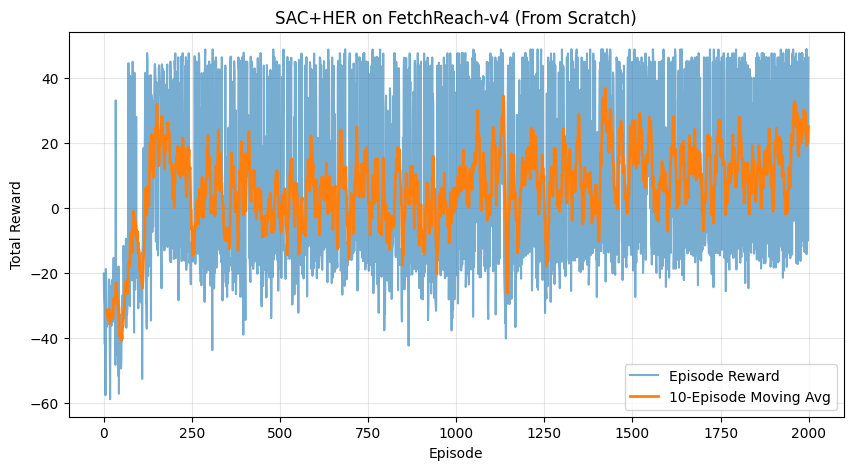

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(rewards, alpha=0.6, label="Episode Reward")
if len(rewards) >= 20:
    rolling = np.convolve(rewards, np.ones(20) / 20, mode='valid')
    plt.plot(range(19, len(rewards)), rolling, label="20-Episode Moving Avg", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("REINFORCE with Baseline on FetchReach-v4")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

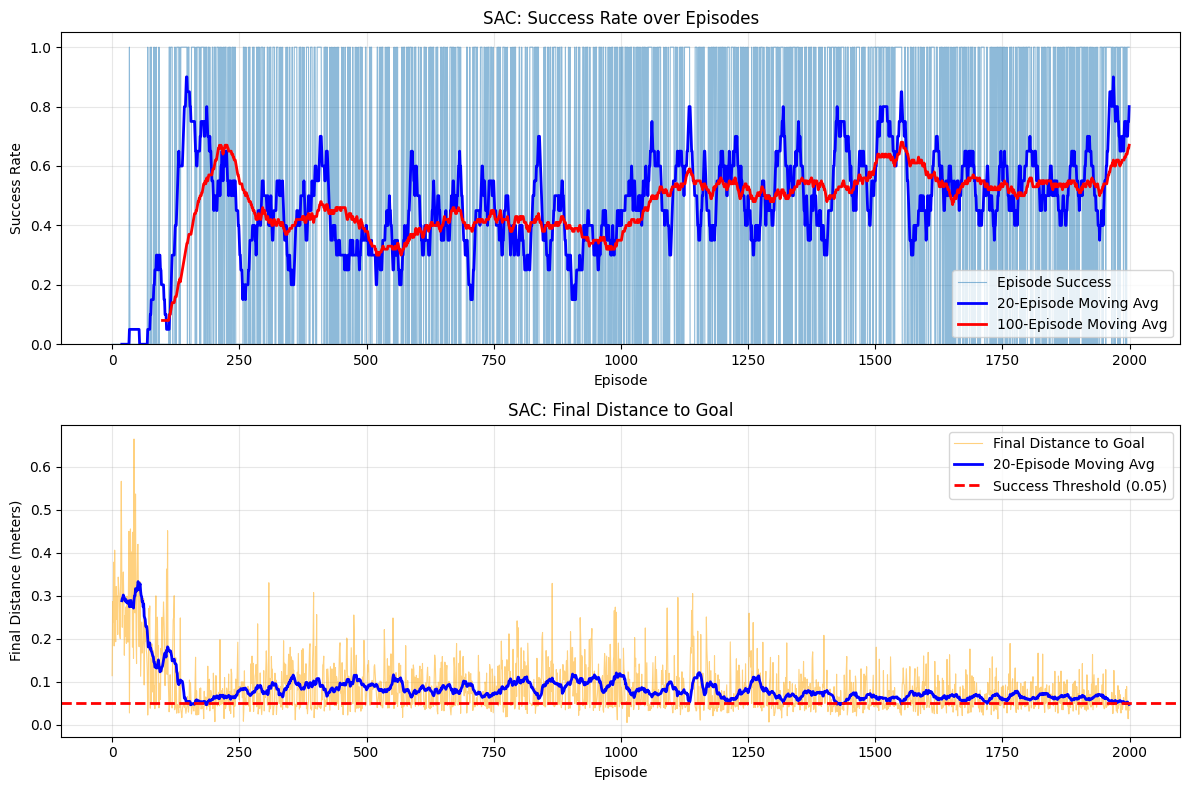

In [ ]:
# Plot Success Rate and Final Distances
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Success rate plot
ax1 = axes[0]
ax1.plot(successes, alpha=0.5, label="Episode Success", linewidth=0.8)
if len(successes) >= 20:
    rolling_success = np.convolve(successes, np.ones(20) / 20, mode='valid')
    ax1.plot(range(19, len(successes)), rolling_success, label="20-Episode Moving Avg", linewidth=2, color='blue')
if len(successes) >= 100:
    rolling_success_100 = np.convolve(successes, np.ones(100) / 100, mode='valid')
    ax1.plot(range(99, len(successes)), rolling_success_100, label="100-Episode Moving Avg", linewidth=2, color='red')
ax1.set_xlabel("Episode")
ax1.set_ylabel("Success Rate")
ax1.set_title("SAC: Success Rate over Episodes")
ax1.set_ylim([0, 1.05])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Final distances plot
ax2 = axes[1]
ax2.plot(distances, alpha=0.5, label="Final Distance to Goal", linewidth=0.8, color='orange')
if len(distances) >= 20:
    rolling_dist = np.convolve(distances, np.ones(20) / 20, mode='valid')
    ax2.plot(range(19, len(distances)), rolling_dist, label="20-Episode Moving Avg", linewidth=2, color='blue')
ax2.axhline(y=0.05, color='r', linestyle='--', linewidth=2, label="Success Threshold (0.05)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Final Distance (meters)")
ax2.set_title("SAC: Final Distance to Goal")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'episode_times' is not defined

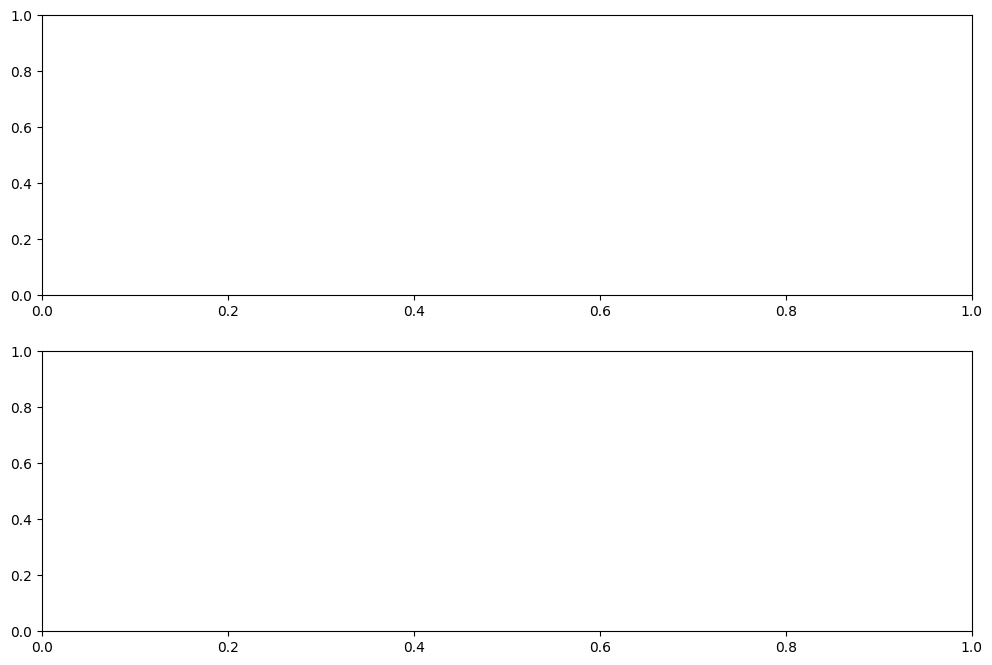

In [ ]:
# Plot Episode Duration Trends
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Episode time plot
ax1 = axes[0]
ax1.plot(episode_times, alpha=0.5, label="Episode Duration", linewidth=0.8, color='purple')
if len(episode_times) >= 20:
    rolling_time = np.convolve(episode_times, np.ones(20) / 20, mode='valid')
    ax1.plot(range(19, len(episode_times)), rolling_time, label="20-Episode Moving Avg", linewidth=2, color='darkblue')
if len(episode_times) >= 100:
    rolling_time_100 = np.convolve(episode_times, np.ones(100) / 100, mode='valid')
    ax1.plot(range(99, len(episode_times)), rolling_time_100, label="100-Episode Moving Avg", linewidth=2, color='red')
ax1.set_xlabel("Episode")
ax1.set_ylabel("Time per Episode (seconds)")
ax1.set_title("SAC: Episode Duration over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cumulative time plot
ax2 = axes[1]
cumulative_time = np.cumsum(episode_times) / 60  # Convert to minutes
ax2.plot(cumulative_time, linewidth=2, color='green', label="Cumulative Training Time")
ax2.fill_between(range(len(cumulative_time)), cumulative_time, alpha=0.3, color='green')
ax2.set_xlabel("Episode")
ax2.set_ylabel("Cumulative Time (minutes)")
ax2.set_title("SAC: Total Training Time Accumulation")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
print(f"\nEpisode Duration Statistics:")
print(f"Mean episode time: {np.mean(episode_times):.3f}s")
print(f"Median episode time: {np.median(episode_times):.3f}s")
print(f"Min episode time: {np.min(episode_times):.3f}s")
print(f"Max episode time: {np.max(episode_times):.3f}s")
print(f"Total training time: {cumulative_time[-1]:.1f} minutes ({cumulative_time[-1]/60:.1f} hours)")

In [10]:
def record_sac_video(agent):
    if os.path.exists(VIDEO_DIR):
        shutil.rmtree(VIDEO_DIR)
    os.makedirs(VIDEO_DIR, exist_ok=True)
    
    env = gym.make("FetchReach-v4", render_mode="rgb_array")
    env = RecordVideo(env, VIDEO_DIR, episode_trigger=lambda x: True, name_prefix="sac_her_final")
    
    obs_dict, _ = env.reset()
    state = flatten_obs(obs_dict)
    done = False
    total_reward = 0.0
    while not done:
        action = agent.select_action(state, evaluate=True)
        obs_dict, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = flatten_obs(obs_dict)
        total_reward += reward
    env.close()
    
    print(f"Video episode reward: {total_reward:.2f}")
    video_files = sorted([f for f in os.listdir(VIDEO_DIR) if f.endswith(".mp4")])
    if video_files:
        display(embed_mp4_in_notebook(os.path.join(VIDEO_DIR, video_files[-1])))
    else:
        print("No video recorded.")

record_sac_video(agent)

c:\Users\AGuy\Documents\GitHub\CS5180_RL_Project\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\AGuy\Documents\GitHub\CS5180_RL_Project\sac_her_scratch_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Video episode reward: -48.00
